In [13]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle

env = gym.make("Acrobot-v1", render_mode=None)

# Turn continuous state space into discrete state space
n_bin_edges = 15
costh1 = np.linspace(env.observation_space.low[0], env.observation_space.high[0], n_bin_edges)
sinth1 = np.linspace(env.observation_space.low[1], env.observation_space.high[1], n_bin_edges)
costh2 = np.linspace(env.observation_space.low[2], env.observation_space.high[2], n_bin_edges)
sinth2 = np.linspace(env.observation_space.low[3], env.observation_space.high[3], n_bin_edges)
omega1 = np.linspace(env.observation_space.low[4], env.observation_space.high[4], n_bin_edges)
omega2 = np.linspace(env.observation_space.low[5], env.observation_space.high[5], n_bin_edges)
state_space = np.vstack((costh1, sinth1, costh2, sinth2, omega1, omega2))

f = open('acrobot.pkl', 'rb')
q = pickle.load(f)
f.close()

rewards_per_episode = []

epoch = 0
while (epoch <= 1000):
    observation = env.reset(seed=0)[0]
    state = np.zeros(state_space.shape[0], dtype=int)

    for i in range(len(observation)):
        state[i] = min(np.digitize(observation[i], state_space[i])-1, q.shape[0]-1)

    new_observation = np.zeros(len(observation))
    new_state = np.zeros(state_space.shape[0], dtype=int)

    rewards = 0               # Total reward over one episode
    terminated = False        # Whether the goal has been reached this episode

    while not terminated:
        action = np.argmax(q[*state, :])

        new_observation, reward, terminated, _, _ = env.step(action)
        for i in range(len(observation)):
            new_state[i] = min(np.digitize(new_observation[i], state_space[i])-1, q.shape[0]-1)

        observation[:] = new_observation
        state[:] = new_state
        
        rewards += reward
        
    rewards_per_episode.append(rewards)

    epoch = epoch + 1

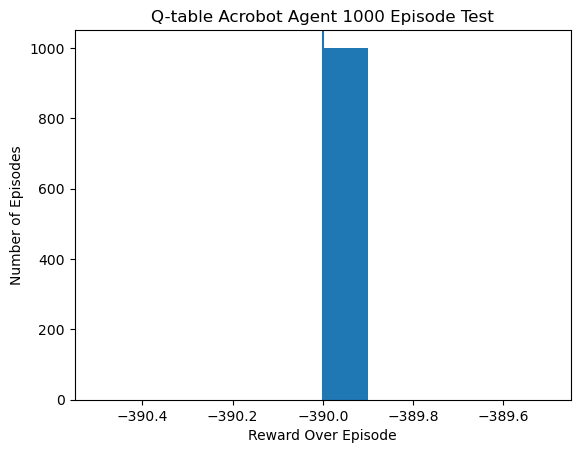

In [14]:
mean_reward = np.mean(rewards_per_episode)
plt.hist(rewards_per_episode)
plt.xlabel("Reward Over Episode")
plt.ylabel("Number of Episodes")
plt.title("Q-table Acrobot Agent 1000 Episode Test")
plt.axvline(mean_reward, label=f'Mean: {mean_reward:.2f}')